In [21]:
# Universidade Presbiteriana Mackenzie - Faculdade de Computacao e Informatica
# Disciplina: Inteligência Artificial - 7J SI - Prof. Dr. Leandro Zerbinatti
#
# Projeto: Análise de Padrões de Escolha e Desempenho de Heróis em Dota 2 por Faixa de Habilidade (MMR)
#
# Integrantes do grupo:
#   - David Haim Raiber | RA 10395618 | 10395618@mackenzista.com.br
#   - Isadora Caetano Brandão de Sousa    | RA 10420646 | 10420646@mackenzista.com.br
#   - Jennifer Aparecida de Sousa Tondade | RA 10420574 | 10420574@mackenzista.com.br
#   - Lucas Lacerda Gomes | RA 10322644 | 10322644@mackenzista.com.br
#
# Sintese do conteúdo deste arquivo:
#   Notebook da analise exploratória do dataset coletado diretamente da OpenDota
#   API (endpoint publico /api/heroStats), que contém carregamento e inspeção
#   dos dados, verificação de valores ausentes, duplicados e inconsistências,
#   estatísticas descritivas e visualizações da distribuição das variáveis de
#   picks e taxa de vitória ao longo das faixas de MMR.
#
# Histórico de atualizações:
#
#   Data       | Autor                                   | Descrição
#   -----------|-----------------------------------------|----------------------------------------
#   06/09/2026 | David, Isadora, Jennifer e Lucas        | Criação do notebook: carga do dataset,
#              |                                         | inspeção, estatistícas descritivas e
#              |                                         | visualizações da analíse exploratória.
#   13/09/2026 | David, Isadora, Jennifer e Lucas        | Verificação da funcionalidade do código.

# Notebook 1: Visualização dos Dados de Heróis do Dota 2 (OpenDota API)

Este notebook realiza a análise exploratória (AED) do dataset **coletado diretamente da OpenDota API**, identificando valores ausentes, discrepantes e inconsistentes, além de descrever a distribuição das variáveis de picks e taxa de vitória por herói e por faixa de MMR.

**Descrição do dataset:** o arquivo dota2_herostats_opendota_live.csv foi gerado por uma coleta feita pelo próprio grupo ao endpoint público GET /api/heroStats da [OpenDota API](https://docs.opendota.com/#tag/hero-stats/paths/~1heroStats/get) ,código de extração na Seção 1. Ele contém estatísticas agregadas e públicas de 92 heróis do jogo Dota 2, número de heróis atualmente retornado pelo endpoint. Para cada herói são informados o **nome**, o **atributo primário** (str=Força, agi=Agilidade, int=Inteligência, all=Universal) e os **papéis estratégicos** (roles), além do número de **picks**, de **vitórias** e da **taxa de vitória (%)** em cada uma das oito faixas de habilidade (MMR): Herald, Guardian, Crusader, Archon, Legend, Ancient, Divine e Immortal. Não há nenhuma informação pessoal ou individualizada de jogadores, apenas estatísticas agregadas por herói e por faixa de MMR.

## 1. Extração dos Dados via OpenDota API

O projeto utiliza dados coletados pelo grupo via requisição HTTP ao endpoint público heroStats da OpenDota API, que não exige autenticação. O código abaixo documenta a extração já foi executado, o CSV gerado por ela é o arquivo carregado na próxima célula:

```python
import requests
import pandas as pd
import time

# Extração dos dados via OpenDota API
# Documentacao: https://docs.opendota.com/#tag/hero-stats/paths/~1heroStats/get
#
# O endpoint retorna, para cada herói do jogo, o atributo primário, os papeís
# estratégicos (roles) e o número de picks/vitórias em cada uma das oito faixas
# de MMR

URL = "https://api.opendota.com/api/heroStats"
BRACKETS = ["Herald", "Guardian", "Crusader", "Archon", "Legend", "Ancient", "Divine", "Immortal"]

resp = requests.get(URL, timeout=30)
resp.raise_for_status()
heroes_json = resp.json()

linhas = []
for h in heroes_json:
    linha = {
        "hero_id": h["id"],
        "hero_name": h["localized_name"],
        "primary_attr": h["primary_attr"],
        "roles": ",".join(h["roles"]),
    }
    for i, bracket in enumerate(BRACKETS, start=1):
        picks = h.get(f"{i}_pick", 0) or 0
        wins = h.get(f"{i}_win", 0) or 0
        winrate = round(100 * wins / picks, 2) if picks > 0 else None
        linha[f"picks_{bracket}"] = picks
        linha[f"wins_{bracket}"] = wins
        linha[f"winrate_{bracket}"] = winrate
    linhas.append(linha)

df_api = pd.DataFrame(linhas)
df_api.to_csv("dota2_herostats_opendota_live.csv", index=False, encoding="utf-8")
print(f"Coleta concluida: {len(df_api)} herois salvos em dota2_herostats_opendota_live.csv")

```

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BRACKETS = ["Herald", "Guardian", "Crusader", "Archon", "Legend", "Ancient", "Divine", "Immortal"]
ATTR_MAP = {"str": "Forca", "agi": "Agilidade", "int": "Inteligencia", "all": "Universal"}

df = pd.read_csv("dota2_herostats_opendota_live.csv")
df["Primary Attribute"] = df["primary_attr"].map(ATTR_MAP)
print(f"Dimensões do dataset: {df.shape}")
df.head()

Dimensões do dataset: (92, 29)


,hero_id,hero_name,primary_attr,roles,picks_Herald,wins_Herald,winrate_Herald,picks_Guardian,wins_Guardian,winrate_Guardian,...,picks_Ancient,wins_Ancient,winrate_Ancient,picks_Divine,wins_Divine,winrate_Divine,picks_Immortal,wins_Immortal,winrate_Immortal,Primary Attribute
0,1,Anti-Mage,agi,"Carry,Escape,Nuker",15444,7560,48.95,50643,25221,49.80,...,56831,28132,49.50,29214,14438,49.42,0,0,NaN,Agilidade
1,2,Axe,str,"Initiator,Durable,Disabler,Carry",19924,10462,52.51,70576,36362,51.52,...,118005,58437,49.52,73308,35562,48.51,0,0,NaN,Forca
2,3,Bane,all,"Support,Disabler,Nuker,Durable",4361,2081,47.72,14181,6813,48.04,...,25082,12914,51.49,22046,11370,51.57,0,0,NaN,Universal
3,4,Bloodseeker,agi,"Carry,Disabler,Nuker,Initiator",10432,5362,51.40,24136,12309,51.00,...,14418,7345,50.94,7218,3740,51.81,0,0,NaN,Agilidade
4,5,Crystal Maiden,int,"Support,Disabler,Nuker",19299,10496,54.39,63841,34021,53.29,...,82336,41702,50.65,49943,24937,49.93,0,0,NaN,Inteligencia


In [23]:
# Verificação de valores ausentes
df.isna().sum()[df.isna().sum() > 0]

winrate_Immortal    92
dtype: int64

In [24]:
# Verificação de heróis duplicados
print("Heróis duplicados:", df["hero_name"].duplicated().sum())
print("Heróis únicos:", df["hero_name"].nunique())

Heróis duplicados: 0
Heróis únicos: 92


In [25]:
# Verificação de consistência: Wins não pode exceder Picks em nenhuma faixa de MMR
incons = pd.DataFrame({
    b: [(df[f"wins_{b}"] > df[f"picks_{b}"]).sum()] for b in BRACKETS
}).T
incons.columns = ["Casos com Wins > Picks"]
incons

,Casos com Wins > Picks
Herald,0
Guardian,0
Crusader,0
Archon,0
Legend,0
Ancient,0
Divine,0
Immortal,0


In [26]:
# Estatísticas descritivas da taxa de vitória por faixa de MMR, exclui Immortal pois vem sem dados
winrate_cols = [f"winrate_{b}" for b in BRACKETS if b != "Immortal"]
df[winrate_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
winrate_Herald,92.0,49.303804,2.834244,41.64,47.7175,48.960,51.7400,55.97
winrate_Guardian,92.0,49.292065,2.702984,42.57,47.8775,49.600,51.2675,55.43
winrate_Crusader,92.0,49.353913,2.604648,42.55,47.8050,49.655,51.1925,55.69
winrate_Archon,92.0,49.404130,2.641861,42.16,47.9475,49.840,51.2525,54.63
winrate_Legend,92.0,49.541957,2.553945,42.23,47.9275,49.935,51.2775,54.20
winrate_Ancient,92.0,49.686522,2.594410,42.46,47.8700,49.900,51.5375,55.30
winrate_Divine,92.0,49.839348,2.561622,43.53,48.4500,49.865,51.5775,56.46


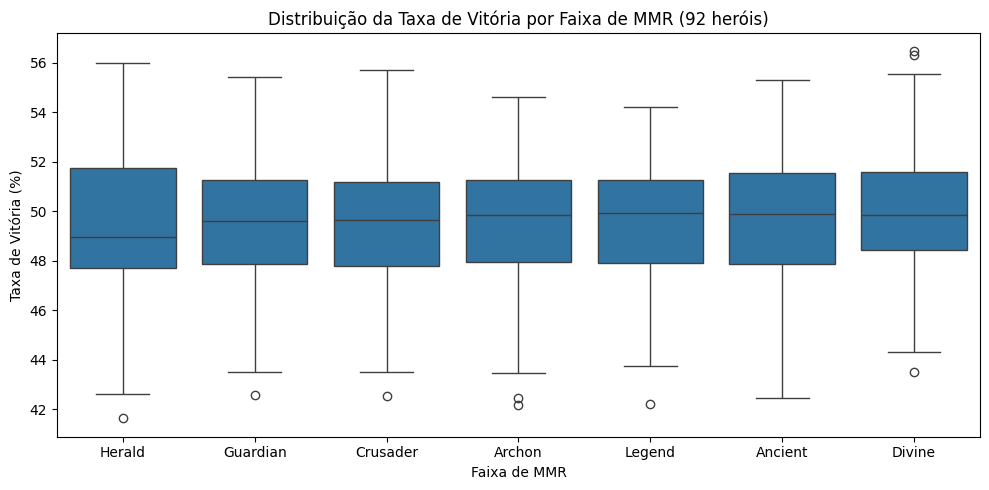

In [27]:
# Distribuição da taxa de vitória por faixa de MMR
plt.figure(figsize=(10, 5))
df_melt = df.melt(value_vars=winrate_cols, var_name="Faixa", value_name="Winrate")
df_melt["Faixa"] = df_melt["Faixa"].str.replace("winrate_", "")
order = [b for b in BRACKETS if b != "Immortal"]
sns.boxplot(data=df_melt, x="Faixa", y="Winrate", order=order)
plt.title("Distribuição da Taxa de Vitória por Faixa de MMR (92 heróis)")
plt.ylabel("Taxa de Vitória (%)")
plt.xlabel("Faixa de MMR")
plt.tight_layout()
plt.show()

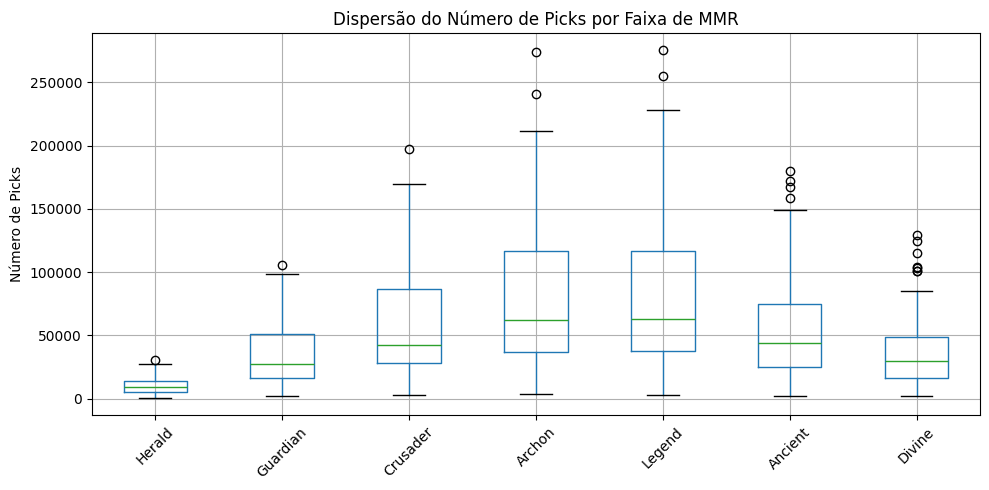

In [28]:
# Dispersão do número de picks por faixa, maior nas faixas extremas com dados: Herald e Divine
picks_cols = [f"picks_{b}" for b in BRACKETS if b != "Immortal"]
plt.figure(figsize=(10, 5))
df[picks_cols].boxplot()
plt.xticks(range(1, len(picks_cols) + 1), [c.replace("picks_", "") for c in picks_cols], rotation=45)
plt.title("Dispersão do Número de Picks por Faixa de MMR")
plt.ylabel("Número de Picks")
plt.tight_layout()
plt.show()

In [29]:
# Tabela cruzada entre Atributo Primário e quantidade de papéis (Roles) por herói
df["Qtde_Roles"] = df["roles"].str.split(",").apply(len)
pd.crosstab(df["Primary Attribute"], df["Qtde_Roles"])

Qtde_Roles,2,3,4,5,6
Primary Attribute,,,,,
Agilidade,6,10,6,4,2
Forca,0,2,7,10,4
Inteligencia,4,10,8,5,0
Universal,0,4,5,5,0


## 6. Observações

- **Fonte dos dados:** Coleta direta via OpenDota API: GET /api/heroStats.
- **Número de heróis:** O endpoint retornou **92 heróis**, não os 124 jogáveis atualmente no Dota 2. A checagem dos hero_id mostra lacunas na sequência, como não há registro para o id 24 e ausência de heróis lançados mais recentemente, o que é uma limitação do próprio endpoint da OpenDota no momento da coleta, e não um erro de tratamento.
- **Faixa Immortal:** picks_Immortal e wins_Immortal vêm zerados para todos os heróis, o que também gera winrate_Immortal nulo. Essa faixa foi mantida no dataset para documentar a limitação, mas é excluída dos cálculos de desempenho (Notebook 2) e das visualizações acima.
- **Valores ausentes:** Nenhum valor ausente fora do já esperado em winrate_Immortal.
- **Outliers:** Taxas de vitória nas faixas com dados, Herald a Divine, situam-se em uma amplitude plausível e a dispersão do número de picks é maior nas faixas extremas com dados que concentram menos partidas que as faixas intermediárias.
- **Duplicados:** Nenhum herói duplicado com o dataset tendo 92 nomes únicos.
- **Inconsistências:** Nenhum caso de wins superior a picks em qualquer faixa, a coluna roles traz múltiplos valores por herói separados por vírgula e precisará ser transformada com multi-hot encoding na etapa de preparação dos dados (Notebook 2).